Import libraries and access the csv

In [27]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/vikasvittanala/basketball3021/refs/heads/nbaseason/NBA%20team%20stats%20csvs/nba_team_stats_00_to_23.csv')
df.head()

,teamstatspk,Team,games_played,wins,losses,win_percentage,Min,points,field_goals_made,field_goals_attempted,...,rebounds,assists,turnovers,steals,blocks,blocks_attempted,personal_fouls,personal_fouls_drawn,plus_minus,season
0,0,Boston Celtics,82,64,18,0.780,3966,9887,3601,7396,...,3799,2207,979,557,538,304,1326,1416,930,2023-24
1,1,Denver Nuggets,82,57,25,0.695,3941,9418,3610,7279,...,3643,2415,1036,585,456,394,1489,1467,431,2023-24
2,2,Oklahoma City Thunder,82,57,25,0.695,3961,9847,3653,7324,...,3447,2223,1039,694,538,419,1545,1548,608,2023-24
3,3,Minnesota Timberwolves,82,56,26,0.683,3961,9264,3383,6974,...,3577,2184,1162,647,497,371,1544,1630,529,2023-24
4,4,LA Clippers,82,51,31,0.622,3941,9481,3473,7108,...,3523,2097,1078,640,413,384,1519,1537,269,2023-24


Structuring: filtering to remove unrelated columns

In [28]:
df2 = df[['teamstatspk', 'Team', 'win_percentage', 'Min', 'points', 'field_goals_made', 'field_goals_attempted', 'field_goal_percentage', 'three_pointers_made', 'three_pointers_attempted', 'three_point_percentage', 'free_throws_made', 'free_throw_attempted', 'free_throw_percentage']]
df2.head()

,teamstatspk,Team,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage
0,0,Boston Celtics,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7
1,1,Denver Nuggets,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2
2,2,Oklahoma City Thunder,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5
3,3,Minnesota Timberwolves,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7
4,4,LA Clippers,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5


Enriching: deriving new attributes 

In [29]:
# 3-point shooting volume: shows what proportion of team's shots are 3-pointers
df2['three_point_shooting_volume'] = df2['three_pointers_attempted'] / df2['field_goals_attempted']
df2.head()

,teamstatspk,Team,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,three_point_shooting_volume
0,0,Boston Celtics,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7,0.470795
1,1,Denver Nuggets,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2,0.351697
2,2,Oklahoma City Thunder,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5,0.382987
3,3,Minnesota Timberwolves,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7,0.384428
4,4,LA Clippers,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5,0.382527


Cleaning: checking for null values

In [30]:
print(df2.isnull().values.any())

False


In [31]:
df2.describe() # Meta Data

,teamstatspk,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,three_point_shooting_volume
count,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000
mean,357.500000,0.499784,3888.927374,8230.385475,3062.220670,6716.244413,45.573743,654.132682,1828.652235,35.588408,1451.811453,1907.463687,76.198883,0.270103
std,206.835684,0.148919,207.684720,712.154467,251.252302,446.747528,1.686295,244.858190,658.066269,1.894185,179.820064,242.163581,3.002977,0.088967
min,0.000000,0.106000,3112.000000,5739.000000,2193.000000,5086.000000,40.800000,214.000000,641.000000,27.800000,889.000000,1198.000000,66.000000,0.100888
25%,178.750000,0.390000,3951.000000,7838.500000,2931.750000,6490.750000,44.400000,466.000000,1302.500000,34.400000,1340.500000,1742.250000,74.400000,0.201132
50%,357.500000,0.512000,3961.000000,8182.500000,3050.500000,6724.000000,45.500000,606.000000,1662.500000,35.500000,1452.000000,1908.000000,76.300000,0.251945
75%,536.250000,0.610000,3971.000000,8641.500000,3208.500000,7018.000000,46.700000,845.500000,2367.250000,36.900000,1568.000000,2067.250000,78.200000,0.345889
max,715.000000,0.890000,4016.000000,10110.000000,3855.000000,7739.000000,50.700000,1363.000000,3721.000000,41.600000,1977.000000,2587.000000,83.900000,0.519475


In [36]:
df2["Team"].unique()

<StringArray>
[                   'Boston Celtics',                    'Denver Nuggets',
             'Oklahoma City Thunder',            'Minnesota Timberwolves',
                       'LA Clippers',                  'Dallas Mavericks',
                   'New York Knicks',                   'Milwaukee Bucks',
              'New Orleans Pelicans',                      'Phoenix Suns',
               'Cleveland Cavaliers',                    'Indiana Pacers',
                'Los Angeles Lakers',                     'Orlando Magic',
                'Philadelphia 76ers',             'Golden State Warriors',
                        'Miami Heat',                  'Sacramento Kings',
                   'Houston Rockets',                     'Chicago Bulls',
                     'Atlanta Hawks',                     'Brooklyn Nets',
                         'Utah Jazz',                 'Memphis Grizzlies',
                   'Toronto Raptors',                 'San Antonio Spurs',
           

In [32]:
#Graphs for Comparison

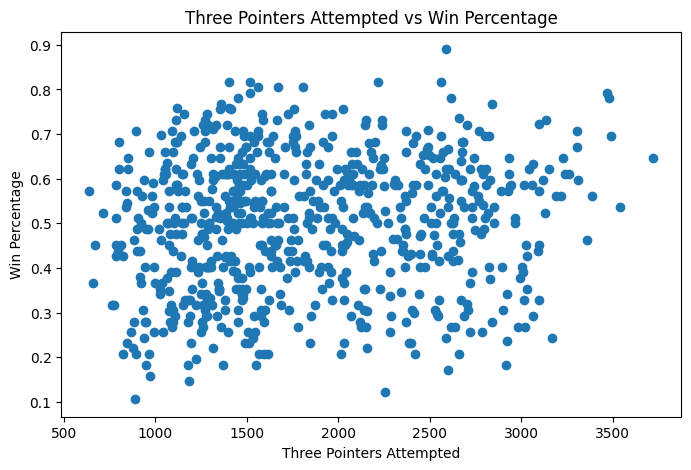

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df2['three_pointers_attempted'], df2['win_percentage'])
plt.xlabel('Three Pointers Attempted')
plt.ylabel('Win Percentage')
plt.title('Three Pointers Attempted vs Win Percentage')
plt.show()

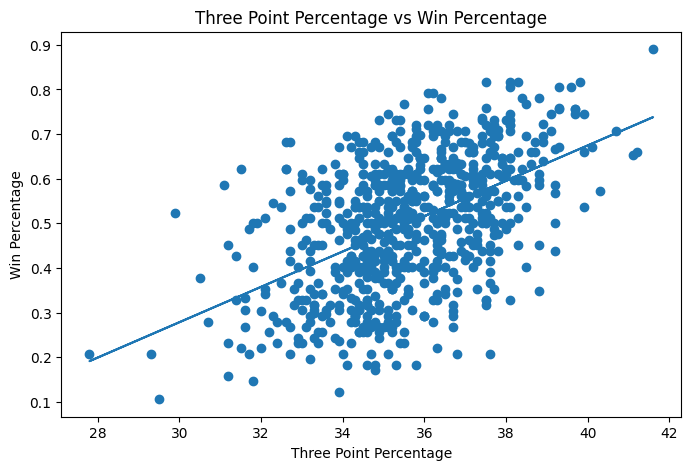

In [34]:
import numpy as np

x = df2['three_point_percentage']
y = df2['win_percentage']


plt.figure(figsize=(8,5))
plt.scatter(x,y)

m, b = np.polyfit(x,y,1)
plt.plot(x, m*x + b)
plt.title('Three Point Percentage vs Win Percentage')
plt.xlabel('Three Point Percentage')
plt.ylabel('Win Percentage')
plt.show()

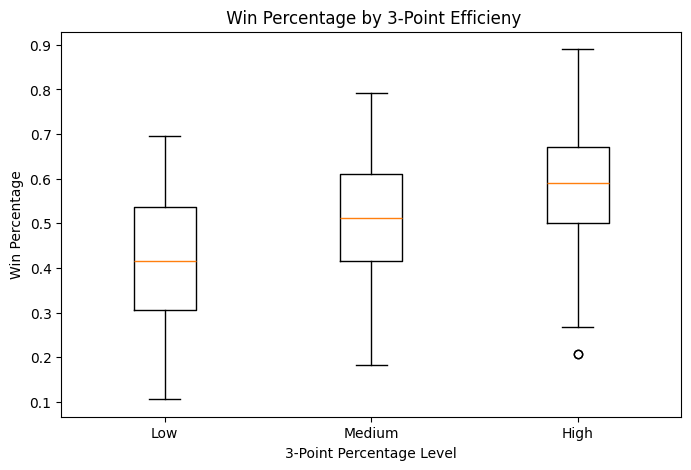

In [35]:
df2['three_pt_pct_group'] = pd.qcut(df2['three_point_percentage'], 3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8,5))

plt.boxplot([df2[df2['three_pt_pct_group'] == g]['win_percentage'] for g in ['Low', 'Medium', 'High']], tick_labels =['Low', 'Medium', 'High'])
plt.title(' Win Percentage by 3-Point Efficieny')
plt.xlabel('3-Point Percentage Level')
plt.ylabel('Win Percentage')
plt.show()